<a href="https://colab.research.google.com/github/vc-alejandro/model_implement_v3/blob/main/bias_variance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Bias, Varianza y Ajuste del Modelo
## Árbol de decisión (manual) sobre Telco Customer Churn



In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/vc-alejandro/model_implement_v3/main"

archivos_necesarios = ["decision_tree_vf.py", "WA_Fn-UseC_-Telco-Customer-Churn.csv"]

for nombre_archivo in archivos_necesarios:
    if not os.path.exists(nombre_archivo):
        url = f"{REPO_RAW}/{nombre_archivo}"
        urllib.request.urlretrieve(url, nombre_archivo)
        print(f"Descargado {nombre_archivo} desde GitHub")
    else:
        print(f"{nombre_archivo} ya disponible localmente")


Descargado decision_tree_vf.py desde GitHub
Descargado WA_Fn-UseC_-Telco-Customer-Churn.csv desde GitHub


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from decision_tree_vf import DecisionTree

pd.set_option('display.max_columns', None)


## 1. Carga y limpieza de datos

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)
df = df.drop(columns=['customerID'])

print(df.shape)
df.head()


(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Separación Train / Validation / Test

A diferencia de la entrega anterior (donde bastaba con train/test),
aquí se necesita un tercer conjunto: el **validation set** se usa
repetidamente mientras se prueban distintos hiperparámetros, y el
**test set** se toca una sola vez, al final, con la configuración ya
elegida, para que la medición final no esté "contaminada" por haber
sido usada también para decidir el modelo.

Proporción usada: 60% train / 20% validation / 20% test, estratificada
por Churn en ambos cortes.


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

# primer corte: 60% train, 40% restante
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# segundo corte: el 40% restante se divide a la mitad -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

for nombre, Xi in [('Train', X_train), ('Validation', X_val), ('Test', X_test)]:
    Xi.reset_index(drop=True, inplace=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train:      {X_train.shape[0]} filas ({X_train.shape[0]/len(df):.0%})')
print(f'Validation: {X_val.shape[0]} filas ({X_val.shape[0]/len(df):.0%})')
print(f'Test:       {X_test.shape[0]} filas ({X_test.shape[0]/len(df):.0%})')


Train:      4225 filas (60%)
Validation: 1409 filas (20%)
Test:       1409 filas (20%)


## 3. Función de evaluación

Se reutiliza la misma lógica de matriz de confusión y métricas de la
entrega anterior, para poder comparar accuracy entre train y
validation en cada configuración de hiperparámetros.


In [6]:
def accuracy(y_real, y_pred):
    aciertos = sum(1 for r, p in zip(y_real, y_pred) if r == p)
    return aciertos / len(y_real)


def evaluar_configuracion(max_depth, min_samples_split):
    modelo = DecisionTree(max_depth=max_depth, min_samples_split=min_samples_split)
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    acc_train = accuracy(y_train, pred_train)
    acc_val = accuracy(y_val, pred_val)

    return acc_train, acc_val


## 4. Diagnóstico inicial: curva de complejidad (max_depth)

Se entrena el árbol con distintas profundidades máximas, midiendo
accuracy en train y en validation en cada una. La brecha entre ambas
curvas es la señal clave para diagnosticar bias y varianza:

- Si **ambas curvas están bajas** (el modelo ni siquiera le atina al
  train) → **bias alto**, **underfitting**.
- Si **train es alto pero validation es mucho más bajo** (brecha
  grande) → **varianza alta**, **overfitting**.
- Si **ambas curvas son altas y cercanas entre sí** → buen ajuste
  (**fitting**), bias y varianza bajos.


In [7]:
# submuestra SOLO para la fase exploratoria (ver nota de rendimiento arriba)
idx_muestra = X_train.sample(1000, random_state=1).index
X_train_muestra = X_train.loc[idx_muestra].reset_index(drop=True)
y_train_muestra = y_train.loc[idx_muestra].reset_index(drop=True)

print(f'Submuestra para tuning: {len(X_train_muestra)} filas (de {len(X_train)} en train completo)')


Submuestra para tuning: 1000 filas (de 4225 en train completo)


In [8]:
def evaluar_configuracion_rapida(max_depth, min_samples_split):
    """Igual que evaluar_configuracion, pero usando la submuestra (mas rapido)."""
    modelo = DecisionTree(max_depth=max_depth, min_samples_split=min_samples_split)
    modelo.fit(X_train_muestra, y_train_muestra)

    pred_train = modelo.predict(X_train_muestra)
    pred_val = modelo.predict(X_val)

    acc_train = accuracy(y_train_muestra, pred_train)
    acc_val = accuracy(y_val, pred_val)

    return acc_train, acc_val


In [9]:
profundidades = [1, 3, 5, 7, 9, 11, 13, 15]
acc_train_lista = []
acc_val_lista = []

for profundidad in profundidades:
    acc_tr, acc_va = evaluar_configuracion_rapida(max_depth=profundidad, min_samples_split=20)
    acc_train_lista.append(acc_tr)
    acc_val_lista.append(acc_va)
    print(f'max_depth={profundidad:2d}  ->  train={acc_tr:.3f}  val={acc_va:.3f}  brecha={acc_tr-acc_va:.3f}')


max_depth= 1  ->  train=0.724  val=0.735  brecha=-0.011
max_depth= 3  ->  train=0.784  val=0.776  brecha=0.008
max_depth= 5  ->  train=0.818  val=0.773  brecha=0.045
max_depth= 7  ->  train=0.836  val=0.770  brecha=0.066
max_depth= 9  ->  train=0.859  val=0.755  brecha=0.104
max_depth=11  ->  train=0.871  val=0.752  brecha=0.119
max_depth=13  ->  train=0.871  val=0.746  brecha=0.125
max_depth=15  ->  train=0.874  val=0.744  brecha=0.130


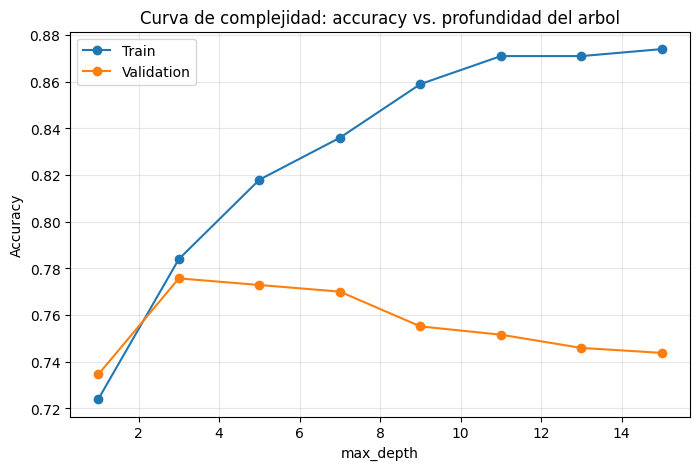

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(profundidades, acc_train_lista, marker='o', label='Train')
plt.plot(profundidades, acc_val_lista, marker='o', label='Validation')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Curva de complejidad: accuracy vs. profundidad del arbol')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Lectura de la curva**:

- En `max_depth=1`, train y validation son similares y relativamente
  bajos (0.724 vs 0.735) → el árbol es demasiado simple para capturar
  el patrón de churn (zona de **bias alto / underfitting**).
- El mejor balance en esta submuestra ocurre alrededor de `max_depth=3`
  (brecha de apenas 0.008). A partir de ahí, la brecha crece de forma
  consistente con la profundidad: de 0.045 en depth=5 hasta 0.130 en
  depth=15, mientras el train sigue subiendo (0.818 → 0.874) y el
  validation **baja** (0.773 → 0.744).



## 5. Diagnóstico con la configuración original (max_depth=5, min_samples_split=20)



In [11]:
modelo_original = DecisionTree(max_depth=5, min_samples_split=20)
modelo_original.fit(X_train, y_train)

acc_train_orig = accuracy(y_train, modelo_original.predict(X_train))
acc_val_orig = accuracy(y_val, modelo_original.predict(X_val))
acc_test_orig = accuracy(y_test, modelo_original.predict(X_test))

print(f'Accuracy train:      {acc_train_orig:.3f}')
print(f'Accuracy validation: {acc_val_orig:.3f}')
print(f'Accuracy test:       {acc_test_orig:.3f}')
print(f'Brecha train-val:    {acc_train_orig - acc_val_orig:.3f}')


Accuracy train:      0.805
Accuracy validation: 0.789
Accuracy test:       0.784
Brecha train-val:    0.017


### Criterio de diagnóstico

Para este ejercicio se toma en cuenta el siguiente treshold:

- **Bias**: alto si accuracy en train < 0.75; bajo si > 0.85; medio en
  el resto. Un accuracy de train bajo significa que el modelo ni
  siquiera logra ajustar los datos que sí vio.
- **Varianza**: alta si la brecha train-validation > 0.08; baja si
  < 0.03; media en el resto. Una brecha grande significa que el modelo
  funciona mucho peor en datos nuevos que en los que memorizó.
- **Nivel de ajuste**: se deriva de combinar ambos — bias alto ⇒
  underfitting; varianza alta ⇒ overfitting; bias medio/bajo y
  varianza baja ⇒ buen ajuste (fit).


In [12]:
def diagnosticar(acc_train, acc_val):
    brecha = acc_train - acc_val

    if acc_train < 0.75:
        bias = 'alto'
    elif acc_train > 0.85:
        bias = 'bajo'
    else:
        bias = 'medio'

    if brecha > 0.08:
        varianza = 'alto'
    elif brecha < 0.03:
        varianza = 'bajo'
    else:
        varianza = 'medio'

    if bias == 'alto':
        ajuste = 'underfitting'
    elif varianza == 'alto':
        ajuste = 'overfitting'
    else:
        ajuste = 'buen ajuste (fit)'

    return bias, varianza, ajuste, brecha


bias_orig, var_orig, ajuste_orig, brecha_orig = diagnosticar(acc_train_orig, acc_val_orig)
print(f'Bias:     {bias_orig}')
print(f'Varianza: {var_orig}')
print(f'Ajuste:   {ajuste_orig}')


Bias:     medio
Varianza: bajo
Ajuste:   buen ajuste (fit)


## 6. Búsqueda exploratoria de hiperparámetros (submuestra)

Primero una búsqueda amplia y rápida (usando la submuestra) para ubicar
la región de hiperparámetros prometedora, y después una segunda pasada
más fina usando el train completo (sección 6.1) para confirmar el
resultado con el dataset real antes de decidir la configuración final.

`min_samples_split` es la segunda palanca de regularización: valores
más altos evitan que el árbol cree hojas basadas en muy pocos ejemplos
(ruido), reduciendo varianza a costa de un poco de bias.


In [13]:
combinaciones = []
for profundidad in [3, 5, 7, 10]:
    for min_split in [20, 50, 100]:
        acc_tr, acc_va = evaluar_configuracion_rapida(max_depth=profundidad, min_samples_split=min_split)
        combinaciones.append({
            'max_depth': profundidad,
            'min_samples_split': min_split,
            'acc_train': acc_tr,
            'acc_val': acc_va,
            'brecha': acc_tr - acc_va,
        })

resultados = pd.DataFrame(combinaciones).sort_values('acc_val', ascending=False)
resultados.head(10)


,max_depth,min_samples_split,acc_train,acc_val,brecha
7,7,50,0.819,0.779276,0.039724
4,5,50,0.810,0.776437,0.033563
0,3,20,0.784,0.775727,0.008273
1,3,50,0.784,0.775727,0.008273
2,3,100,0.784,0.775727,0.008273
5,5,100,0.800,0.773598,0.026402
10,10,50,0.824,0.773598,0.050402
3,5,20,0.818,0.772889,0.045111
8,7,100,0.802,0.772889,0.029111
6,7,20,0.836,0.770050,0.065950


### 6.1 Grid fino sobre el TRAIN COMPLETO

La búsqueda anterior usa la submuestra (solo para ubicar la región
prometedora rápidamente); sus valores absolutos de accuracy no son
directamente comparables con el resto del análisis, que usa el train
completo. Aquí se re-evalúan, ya con el train completo, algunas
combinaciones alrededor de esa región — incluyendo valores más altos
de `min_samples_split` de lo que la búsqueda rápida sugería, ya que en
la práctica esta regularización solo se vuelve determinante con más
datos disponibles.


In [14]:
combinaciones_finas = [
    (5, 50), (6, 100), (7, 150), (7, 200), (8, 200),
]

resultados_finos = []
for profundidad, min_split in combinaciones_finas:
    modelo = DecisionTree(max_depth=profundidad, min_samples_split=min_split)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy(y_train, modelo.predict(X_train))
    acc_va = accuracy(y_val, modelo.predict(X_val))
    resultados_finos.append({
        'max_depth': profundidad,
        'min_samples_split': min_split,
        'acc_train': acc_tr,
        'acc_val': acc_va,
        'brecha': acc_tr - acc_va,
    })
    print(f'depth={profundidad} min_split={min_split} -> train={acc_tr:.3f} val={acc_va:.3f} brecha={acc_tr-acc_va:.3f}')

resultados_finos = pd.DataFrame(resultados_finos).sort_values('acc_val', ascending=False)
resultados_finos


depth=5 min_split=50 -> train=0.805 val=0.789 brecha=0.017
depth=6 min_split=100 -> train=0.813 val=0.792 brecha=0.021
depth=7 min_split=150 -> train=0.815 val=0.792 brecha=0.023
depth=7 min_split=200 -> train=0.811 val=0.795 brecha=0.016
depth=8 min_split=200 -> train=0.811 val=0.795 brecha=0.016


,max_depth,min_samples_split,acc_train,acc_val,brecha
4,8,200,0.810651,0.794890,0.015761
3,7,200,0.810651,0.794890,0.015761
2,7,150,0.815385,0.792051,0.023334
1,6,100,0.813254,0.792051,0.021203
0,5,50,0.805444,0.788502,0.016941


In [ ]:
mejor = resultados_finos.iloc[0]
print('Mejor configuracion (grid fino, train completo):')
print(f"  max_depth={int(mejor['max_depth'])}, min_samples_split={int(mejor['min_samples_split'])}")
print(f"  acc_train={mejor['acc_train']:.3f}  acc_val={mejor['acc_val']:.3f}  brecha={mejor['brecha']:.3f}")


Mejor configuracion (grid fino, train completo):
  max_depth=8, min_samples_split=200
  acc_train=0.811  acc_val=0.795  brecha=0.016


## 7. Evaluación final del modelo ajustado sobre TEST

El test set no se tocó en ningún paso anterior — se usa una única vez,
aquí, con la configuración ya elegida usando validation.


In [ ]:
modelo_final = DecisionTree(
    max_depth=int(mejor['max_depth']),
    min_samples_split=int(mejor['min_samples_split']),
)
modelo_final.fit(X_train, y_train)

acc_train_final = accuracy(y_train, modelo_final.predict(X_train))
acc_val_final = accuracy(y_val, modelo_final.predict(X_val))
acc_test_final = accuracy(y_test, modelo_final.predict(X_test))

print(f'Accuracy train:      {acc_train_final:.3f}')
print(f'Accuracy validation: {acc_val_final:.3f}')
print(f'Accuracy test:       {acc_test_final:.3f}')

bias_final, var_final, ajuste_final, brecha_final = diagnosticar(acc_train_final, acc_val_final)
print(f'\nBias:     {bias_final}')
print(f'Varianza: {var_final}')
print(f'Ajuste:   {ajuste_final}')


Accuracy train:      0.811
Accuracy validation: 0.795
Accuracy test:       0.786

Bias:     medio
Varianza: bajo
Ajuste:   buen ajuste (fit)


## 8. Comparación: modelo original vs. modelo ajustado

In [ ]:
comparacion = pd.DataFrame({
    'Original (depth=5, split=20)': {
        'acc_train': acc_train_orig,
        'acc_val': acc_val_orig,
        'acc_test': acc_test_orig,
        'brecha_train_val': acc_train_orig - acc_val_orig,
        'bias': bias_orig,
        'varianza': var_orig,
        'ajuste': ajuste_orig,
    },
    'Ajustado': {
        'acc_train': acc_train_final,
        'acc_val': acc_val_final,
        'acc_test': acc_test_final,
        'brecha_train_val': acc_train_final - acc_val_final,
        'bias': bias_final,
        'varianza': var_final,
        'ajuste': ajuste_final,
    },
})
comparacion


,"Original (depth=5, split=20)",Ajustado
acc_train,0.805444,0.810651
acc_val,0.788502,0.79489
acc_test,0.783534,0.786373
brecha_train_val,0.016941,0.015761
bias,medio,medio
varianza,bajo,bajo
ajuste,buen ajuste (fit),buen ajuste (fit)


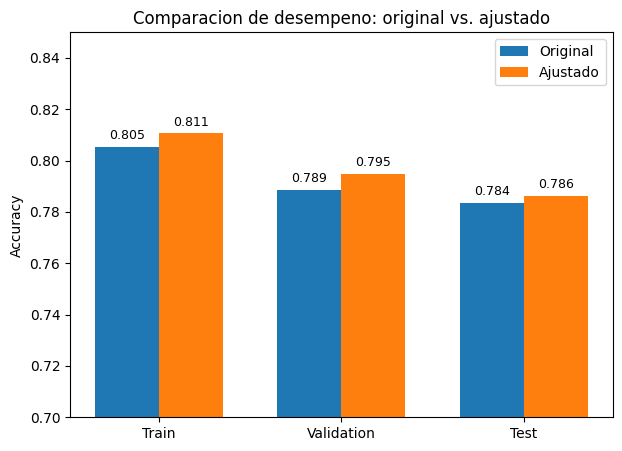

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
categorias = ['Train', 'Validation', 'Test']
x = np.arange(len(categorias))
ancho = 0.35

valores_original = [acc_train_orig, acc_val_orig, acc_test_orig]
valores_ajustado = [acc_train_final, acc_val_final, acc_test_final]

ax.bar(x - ancho/2, valores_original, ancho, label='Original')
ax.bar(x + ancho/2, valores_ajustado, ancho, label='Ajustado')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.70, 0.85)  # zoom: la mejora es real pero modesta (~0.5-0.6 pp)
ax.set_title('Comparacion de desempeno: original vs. ajustado')
ax.legend()

# anotar el valor exacto sobre cada barra
for i, (v_orig, v_ajus) in enumerate(zip(valores_original, valores_ajustado)):
    ax.text(i - ancho/2, v_orig + 0.003, f'{v_orig:.3f}', ha='center', fontsize=9)
    ax.text(i + ancho/2, v_ajus + 0.003, f'{v_ajus:.3f}', ha='center', fontsize=9)

plt.show()
